In [1]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.holtwinters import ExponentialSmoothing

In [2]:
N_SAMPLES = 1000

задаем временной ряд

In [3]:
t = np.arange(N_SAMPLES)

y = (
    10 * np.sin(2 * np.pi * t / 50)  # синусоида (сезонность)
    + 0.02 * t                       # тренд
    + np.random.normal(0, 1, size=N_SAMPLES)  # шум
)

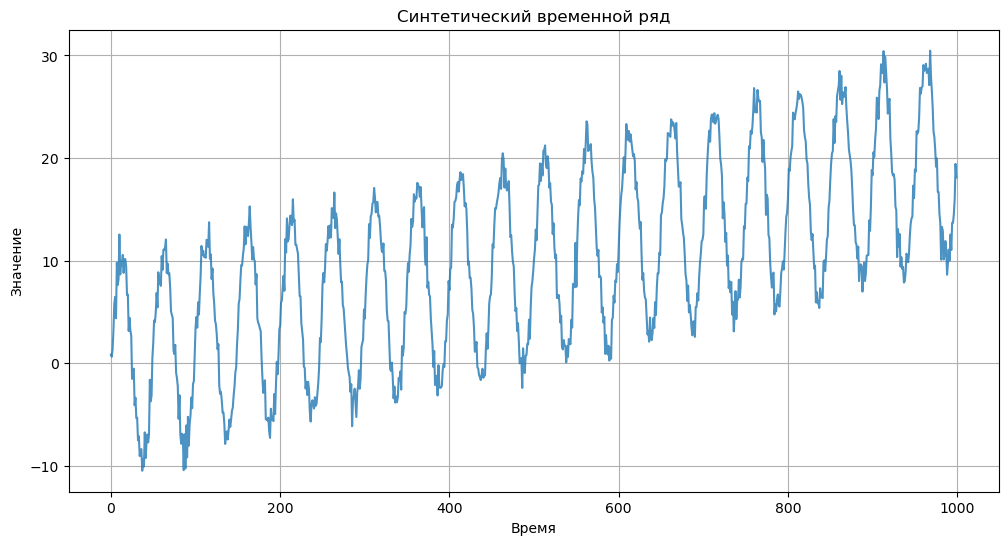

In [4]:
plt.figure(figsize=(12, 6))
plt.plot(y, alpha=0.8)
plt.title("Синтетический временной ряд")
plt.xlabel("Время")
plt.ylabel("Значение")
plt.grid(True)
plt.show()

In [5]:
split_idx = int(len(y) * 0.8)
y_train = y[:split_idx]
y_test = y[split_idx:]

Модель AR (авторегрессия)

In [6]:
model_AR = AutoReg(y_train, lags=40)
fitted_model_AR = model_AR.fit()
n_predictions_AR = len(y_test)
predictions_AR = fitted_model_AR.forecast(steps=n_predictions_AR)

model_AR

In [7]:
mean_absolute_error(y_test, predictions_AR)

0.9019187325299282

In [8]:
np.sqrt(mean_squared_error(y_test, predictions_AR))

np.float64(1.117950803653425)

Модель ETS (Error-Trend-Seasonality)

In [9]:
model_ETS = ExponentialSmoothing(y_train, trend="add", damped_trend=True, seasonal="add", seasonal_periods=50)
fitted_model_ETS = model_ETS.fit()
n_predictions_ETS = len(y_test)
predictions_ETS = fitted_model_ETS.forecast(steps=n_predictions_ETS)

model_ETS

In [10]:
mean_absolute_error(y_test, predictions_ETS)

1.0375419216451467

In [11]:
np.sqrt(mean_squared_error(y_test, predictions_ETS))

np.float64(1.3264943605067971)

Сравнение прогнозов AR и ETS на графике

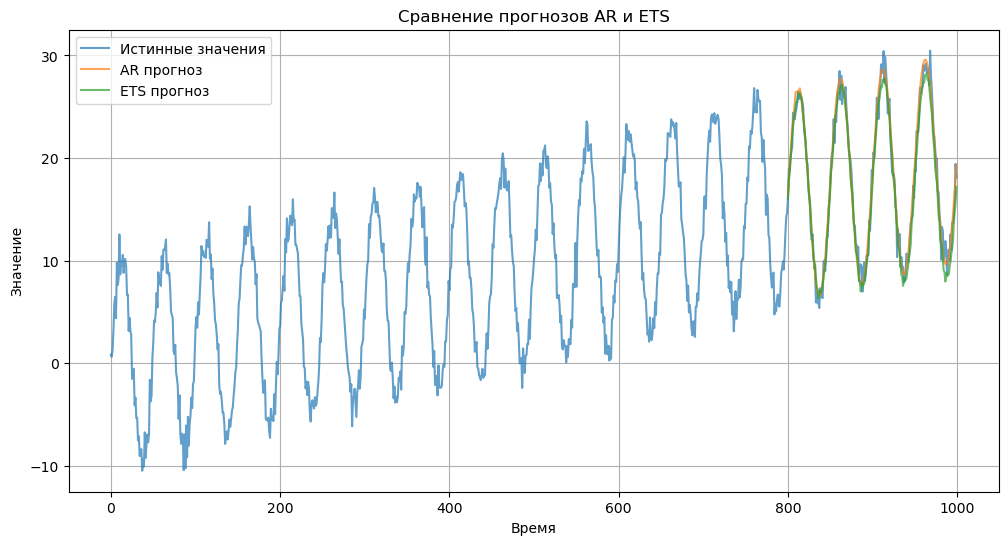

In [12]:
n_train = len(y_train)
total_len = n_train + len(y_test)

plt.figure(figsize=(12, 6))

plt.plot(range(total_len), np.concatenate([y_train, y_test]), label="Истинные значения", alpha=0.7)
plt.plot(range(n_train, total_len), predictions_AR, label="AR прогноз", alpha=0.7)
plt.plot(range(n_train, total_len), predictions_ETS, label="ETS прогноз", alpha=0.7)

plt.title("Сравнение прогнозов AR и ETS")
plt.xlabel("Время")
plt.ylabel("Значение")
plt.legend()
plt.grid(True)